# Non-Uniform Azimuthal Poisson Solver:
# Direct Scattered-Data Methods vs. Uniform FFT with Interpolation

$$
u(r, \theta) = r^2 \left(R^2 - r^2\right) \exp\!\left( - \left[ \frac{\sin((\theta - \theta_0)/2)}{\sigma} \right]^2 \right)
$$

This problem is strictly $2\pi$-periodic and smooth, featuring a localized
angular wave with width parameter $\sigma \ll 1$ and homogeneous Dirichlet
boundary conditions $u(R, \theta)=0$.

All methods begin from the same clustered angular measurements. Adapted NUFFT
and Adapted NUDFT consume those measurements directly. The Uniform FFT baseline
first uses periodic linear interpolation to place the same data on a uniform
angular grid before solving.

In [26]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.paper.helpers import (
    get_azimuthal_gaussian_ridge_problem,
    run_all_algorithms_NxM_study,
    plot_solution_and_grids,
    plot_accuracy_faceted_by_method,
    plot_accuracy_from_df,
    plot_3x3_disk_error_comparison,
    plot_adapted_vs_highres_uniform,
    render_combined_error_table,
    render_combined_runtime_table,
    plot_extreme_runtime_2x2,
)

## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [27]:
R = 1.0                      # Disk radius
SIGMA = 0.12                 # Width of the Gaussian ridge
THETA_0 = np.pi              # Center angle of ridge (moved to pi for symmetry)

# Solver & Radial Grid Settings
QUAD_RULE = 2                # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1                # 1: Dirichlet, 2: Neumann

# Clustered angular measurement grid.
# Keep this below 1.0 to preserve a monotone, well-conditioned mapping.
CLUSTER_STRENGTH = 0.2

# N vs M Sweep Grids
N_VALUES = [16, 32, 64, 128]
M_VALUES = [16, 32, 64, 128]

# Data-efficiency comparison:
# NUFFT/NUDFT use N_LOW_ADAPT direct clustered measurements.
# Uniform FFT uses N_HIGH_UNIFORM clustered measurements, then interpolates.
N_LOW_ADAPT = 32
N_HIGH_UNIFORM = 128
M_FIXED_PLOTS = 64

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

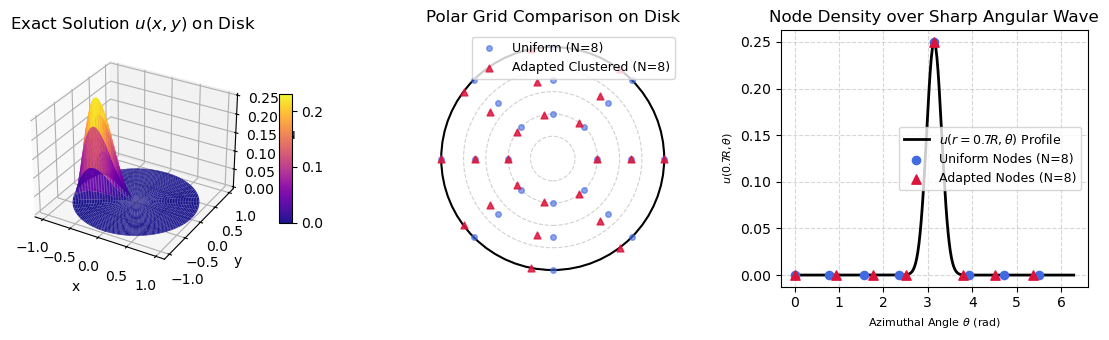

In [28]:
# Construct benchmark problem (Chebyshev boundary layer)
problem = get_azimuthal_gaussian_ridge_problem(
    R=R, theta_0=THETA_0, sigma=SIGMA
)

# Visualize 3D solution surface and 2D polar lattice
plot_solution_and_grids(
    problem=problem,
    N_adapt=8,
    N_unif=8,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,   # now 0.0
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [29]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE,
)

Computing N vs M Grid Matrix: 100%|██████████| 48/48 [00:07<00:00,  6.32it/s]


## 4. $L_2$ Error 
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [30]:
# Relative L2 Error Tables for each algorithm
combined_error = render_combined_error_table(df_results, value_col="L2_rel")


Relative L2 Error — N vs M, All Methods


## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

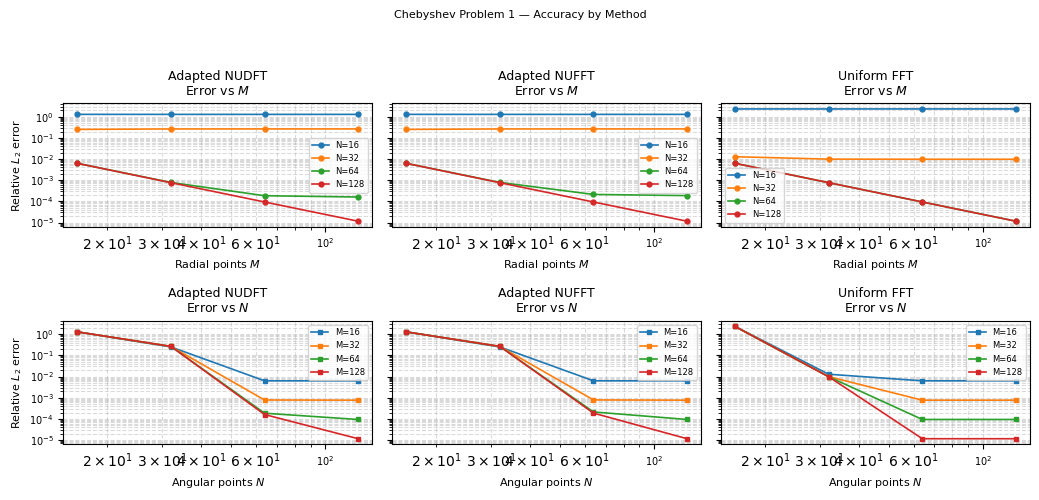

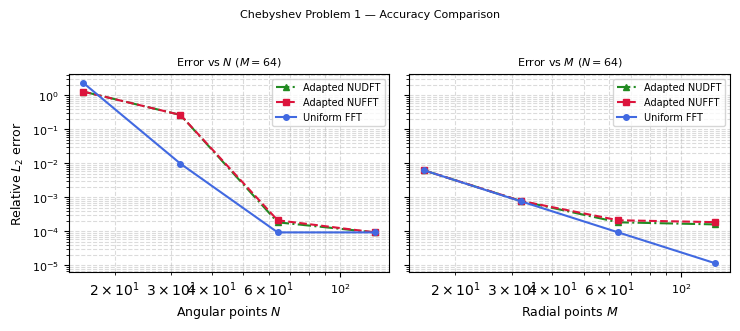

In [31]:
plot_accuracy_faceted_by_method(df_results, N_values=N_VALUES, M_values=M_VALUES)

plot_accuracy_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).

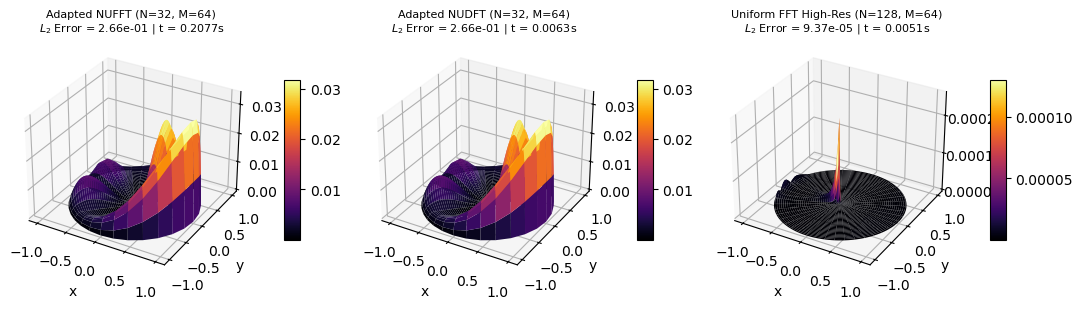

In [32]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)

Runtime Tables ($N$ vs. $M$)



Combined Runtime Table — Methods × M (index N)


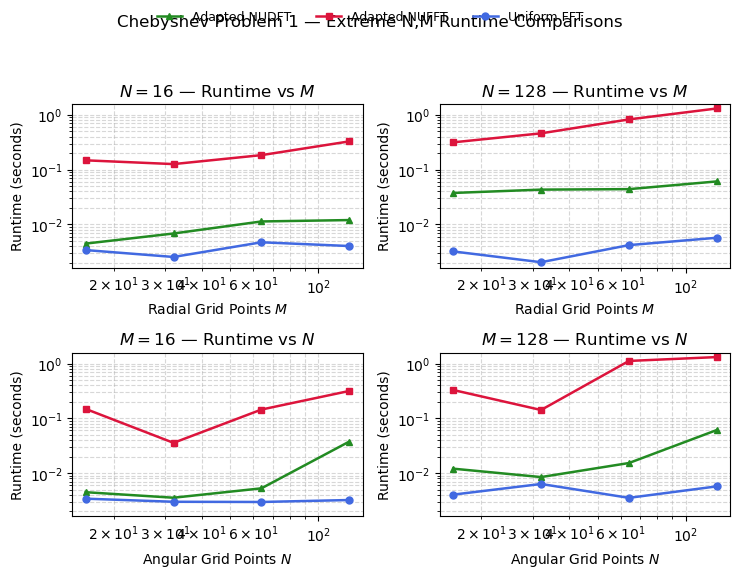

In [33]:
# Runtime (seconds) Tables for each algorithm
combined_runtime = render_combined_runtime_table(df_results)

plot_extreme_runtime_2x2(df_results)